##Install

In [ ]:
!pip -q install "pennylane==0.36.0" "autoray==0.6.11" "numpy==1.26.4" scikit-learn matplotlib pillow tqdm

#Restart runtime after install

In [ ]:
import os
os.kill(os.getpid(), 9)

##Import

In [ ]:
import numpy as np
import pennylane as qml
import torch
import sklearn
import matplotlib

print("NumPy:", np.__version__)
print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("CUDA available:", torch.cuda.is_available())

NumPy: 1.26.4
PennyLane: 0.36.0
Torch: 2.10.0+cu128
sklearn: 1.6.1
matplotlib: 3.10.0
CUDA available: True


In [ ]:
!pip -q install --no-deps "pennylane==0.36.0" "autoray==0.6.11"
!pip -q install "numpy==1.26.4" scikit-learn matplotlib pillow tqdm

In [ ]:
import os
import json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

import pennylane as qml
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("CUDA available:", torch.cuda.is_available())

NumPy: 1.26.4
Torch: 2.10.0+cu128
PennyLane: 0.36.0
CUDA available: True


##Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Seed and device

In [ ]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)

Using device: cuda


##Paths

In [ ]:
project_root_candidates = [
    Path("/content/drive/MyDrive/Project Test 4"),
    Path("/content/drive/MyDrive/Project test 4"),
]

project_root = None
for p in project_root_candidates:
    if p.exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError("Project Test 4 folder not found in MyDrive.")

patches_dir = project_root / "DFU" / "Patches"
normal_dir = patches_dir / "Normal(Healthy skin)"
abnormal_dir = patches_dir / "Abnormal(Ulcer)"

if not patches_dir.exists():
    raise FileNotFoundError(f"Patches folder not found: {patches_dir}")
if not normal_dir.exists():
    raise FileNotFoundError(f"Normal folder not found: {normal_dir}")
if not abnormal_dir.exists():
    raise FileNotFoundError(f"Abnormal folder not found: {abnormal_dir}")

output_dir = project_root / "outputs_model_4"
output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Normal exists:", normal_dir.exists())
print("Abnormal exists:", abnormal_dir.exists())
print("Output dir:", output_dir)

Project root: /content/drive/MyDrive/Project Test 4
Normal exists: True
Abnormal exists: True
Output dir: /content/drive/MyDrive/Project Test 4/outputs_model_4


##Config

In [ ]:
CONFIG = {
    "image_size": 224,
    "batch_size": 16,
    "num_workers": 0,  # safer in Colab
    "train_size": 0.70,
    "val_size": 0.15,
    "test_size": 0.15,

    "backbone": "resnet18",
    "pretrained": True,
    "dropout": 0.30,

    "classical_hidden": 64,
    "fusion_hidden": 32,

    "feature_dim": 4,
    "n_qubits": 4,
    "n_q_layers": 2,

    "noise_prob": 0.01,
    "amp_damp_prob": 0.01,

    "lr_stage1": 1e-4,
    "lr_stage2": 5e-5,
    "weight_decay": 1e-4,

    "epochs_stage1": 10,
    "epochs_stage2": 10,
    "early_stopping_patience": 3,
    "grad_clip": 1.0,

    "use_weighted_sampler": True,
}
CONFIG

{'image_size': 224,
 'batch_size': 16,
 'num_workers': 0,
 'train_size': 0.7,
 'val_size': 0.15,
 'test_size': 0.15,
 'backbone': 'resnet18',
 'pretrained': True,
 'dropout': 0.3,
 'classical_hidden': 64,
 'fusion_hidden': 32,
 'feature_dim': 4,
 'n_qubits': 4,
 'n_q_layers': 2,
 'noise_prob': 0.01,
 'amp_damp_prob': 0.01,
 'lr_stage1': 0.0001,
 'lr_stage2': 5e-05,
 'weight_decay': 0.0001,
 'epochs_stage1': 10,
 'epochs_stage2': 10,
 'early_stopping_patience': 3,
 'grad_clip': 1.0,
 'use_weighted_sampler': True}

##Load file list

In [ ]:
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([str(p) for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts])

normal_images = list_images(normal_dir)
abnormal_images = list_images(abnormal_dir)

print("Normal images:", len(normal_images))
print("Abnormal images:", len(abnormal_images))

if len(normal_images) == 0 or len(abnormal_images) == 0:
    raise ValueError("No images found in one or both folders.")

samples = [(p, 0) for p in normal_images] + [(p, 1) for p in abnormal_images]
random.shuffle(samples)

image_paths = [x[0] for x in samples]
labels = [x[1] for x in samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels,
    test_size=(1 - CONFIG["train_size"]),
    random_state=SEED,
    stratify=labels,
)

relative_test_size = CONFIG["test_size"] / (CONFIG["val_size"] + CONFIG["test_size"])

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_labels,
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Normal images: 543
Abnormal images: 512
Train: 738
Val: 158
Test: 159


##Transforms and dataset

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = DFUDataset(train_paths, train_labels, transform=train_transform)
val_dataset = DFUDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = DFUDataset(test_paths, test_labels, transform=eval_transform)

##DataLoaders

In [ ]:
if CONFIG["use_weighted_sampler"]:
    class_counts = np.bincount(train_labels)
    sample_weights = [1.0 / class_counts[label] for label in train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        sampler=sampler,
        num_workers=CONFIG["num_workers"],
        pin_memory=PIN_MEMORY
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=PIN_MEMORY
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 47
Val batches: 10
Test batches: 10


##Quick visual check

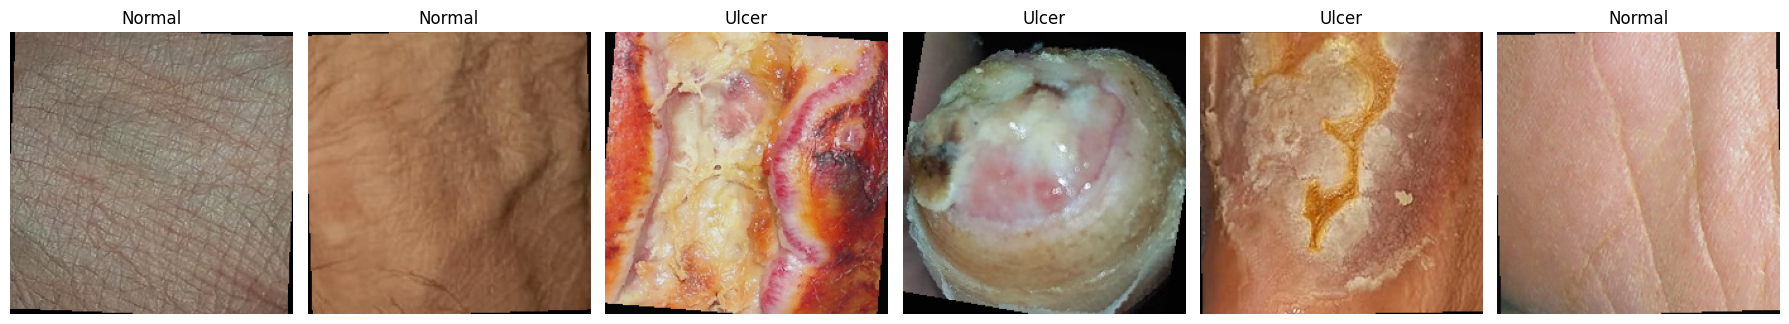

In [ ]:
def show_batch(dataset, n=6):
    fig, axes = plt.subplots(1, n, figsize=(18, 4))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title("Ulcer" if label == 1 else "Normal")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=6)

##Metrics and threshold search

In [ ]:
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        metrics["roc_auc"] = 0.0

    cm = confusion_matrix(y_true, y_pred)
    metrics["confusion_matrix"] = cm.tolist()

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics["specificity"] = float(tn / max(tn + fp, 1))
        metrics["sensitivity"] = float(tp / max(tp + fn, 1))
    else:
        metrics["specificity"] = 0.0
        metrics["sensitivity"] = 0.0

    metrics["threshold"] = float(threshold)
    return metrics

def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_t = 0.5
    best_f1 = -1.0

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return float(best_t), float(best_f1)

##Quantum layer

In [ ]:
def make_quantum_layer(
    n_qubits=4,
    n_q_layers=2,
    use_noise=False,
    noise_prob=0.01,
    amp_damp_prob=0.01,
):
    backend = "default.mixed" if use_noise else "default.qubit"
    dev = qml.device(backend, wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="best")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")

        for layer in range(n_q_layers):
            for i in range(n_qubits):
                qml.Rot(
                    weights[layer, i, 0],
                    weights[layer, i, 1],
                    weights[layer, i, 2],
                    wires=i
                )
                if use_noise:
                    qml.DepolarizingChannel(noise_prob, wires=i)
                    qml.AmplitudeDamping(amp_damp_prob, wires=i)

            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
                if use_noise:
                    qml.DepolarizingChannel(noise_prob, wires=(i + 1) % n_qubits)

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_q_layers, n_qubits, 3)}
    return qml.qnn.TorchLayer(qnode, weight_shapes)

##Backbone helper

In [ ]:
def build_backbone():
    if CONFIG["backbone"] == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if CONFIG["pretrained"] else None
        backbone = models.resnet18(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        return backbone, in_features
    raise ValueError("Only resnet18 enabled in Model_4 for stability.")

##Model definitions

In [ ]:
class ClassicalBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone, in_features = build_backbone()
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(CONFIG["dropout"]),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(CONFIG["dropout"]),
            nn.Linear(64, 1)
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_layer4_only(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True

    def forward(self, x):
        f = self.backbone(x)
        return self.head(f)


class HybridFusionModel(nn.Module):
    def __init__(self, use_noise=False):
        super().__init__()
        self.backbone, in_features = build_backbone()

        self.shared_projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(CONFIG["dropout"]),
        )

        self.classical_branch = nn.Sequential(
            nn.Linear(256, CONFIG["classical_hidden"]),
            nn.ReLU(),
            nn.Dropout(CONFIG["dropout"])
        )

        self.quantum_prep = nn.Sequential(
            nn.Linear(256, CONFIG["feature_dim"]),
            nn.Tanh()
        )

        self.quantum_layer = make_quantum_layer(
            n_qubits=CONFIG["n_qubits"],
            n_q_layers=CONFIG["n_q_layers"],
            use_noise=use_noise,
            noise_prob=CONFIG["noise_prob"],
            amp_damp_prob=CONFIG["amp_damp_prob"],
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(CONFIG["classical_hidden"] + CONFIG["n_qubits"], CONFIG["fusion_hidden"]),
            nn.ReLU(),
            nn.Dropout(CONFIG["dropout"]),
            nn.Linear(CONFIG["fusion_hidden"], 1)
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_layer4_only(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True

    def forward(self, x):
        f = self.backbone(x)
        s = self.shared_projector(f)

        c = self.classical_branch(s)
        q_in = self.quantum_prep(s)

        q_out = []
        for i in range(q_in.shape[0]):
            q_out.append(self.quantum_layer(q_in[i]))
        q_out = torch.stack(q_out, dim=0)

        fused = torch.cat([c, q_out], dim=1)
        return self.fusion_head(fused)

##Train/eval helpers

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train(train)

    losses = []
    y_true = []
    y_prob = []

    progress = tqdm(loader, leave=False)

    for images, labels in progress:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG["grad_clip"])
                optimizer.step()

        losses.append(loss.item())
        y_true.extend(labels.detach().cpu().numpy().flatten().astype(int).tolist())
        y_prob.extend(probs.detach().cpu().numpy().flatten().tolist())

        progress.set_description(("Train" if train else "Eval") + f" Loss: {loss.item():.4f}")

    avg_loss = float(np.mean(losses))
    return avg_loss, np.array(y_true), np.array(y_prob)

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    y_true = []
    y_prob = []

    for images, labels in loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
        y_true.extend(labels.numpy().tolist())
        y_prob.extend(probs.tolist())

    return np.array(y_true), np.array(y_prob)

##Main training function

In [ ]:
def train_model(model, model_name):
    print("\n" + "=" * 80)
    print(f"STARTING TRAINING: {model_name}")
    print("=" * 80)

    model = model.to(DEVICE)

    train_class_counts = np.bincount(train_labels)
    neg_count = train_class_counts[0]
    pos_count = train_class_counts[1]
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = {
        "train_loss": [], "val_loss": [],
        "train_f1": [], "val_f1": [],
        "train_auc": [], "val_auc": [],
        "stage": []
    }

    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    global_epoch = 0
    patience_counter = 0

    def save_best():
        torch.save(
            {
                "state_dict": best_state,
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "model_name": model_name,
                "config": CONFIG,
            },
            output_dir / f"best_{model_name}.pt"
        )

    # Stage 1
    model.freeze_backbone()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=CONFIG["lr_stage1"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

    print("\nStage 1: frozen backbone training")
    for _ in range(CONFIG["epochs_stage1"]):
        global_epoch += 1
        train_loss, train_y_true, train_y_prob = run_epoch(model, train_loader, criterion, optimizer=optimizer, train=True)
        val_loss, val_y_true, val_y_prob = run_epoch(model, val_loader, criterion, optimizer=None, train=False)

        scheduler.step(val_loss)

        train_t, _ = find_best_threshold(train_y_true, train_y_prob)
        val_t, _ = find_best_threshold(val_y_true, val_y_prob)

        train_metrics = compute_binary_metrics(train_y_true, train_y_prob, threshold=train_t)
        val_metrics = compute_binary_metrics(val_y_true, val_y_prob, threshold=val_t)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_auc"].append(train_metrics["roc_auc"])
        history["val_auc"].append(val_metrics["roc_auc"])
        history["stage"].append("stage1")

        print(f"Epoch {global_epoch:02d} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val F1 {val_metrics['f1']:.4f} | Val AUC {val_metrics['roc_auc']:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = global_epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            save_best()
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["early_stopping_patience"]:
            print("Early stopping triggered in Stage 1.")
            break

    # Stage 2
    model.unfreeze_layer4_only()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=CONFIG["lr_stage2"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

    print("\nStage 2: fine-tuning last backbone block")
    for _ in range(CONFIG["epochs_stage2"]):
        global_epoch += 1
        train_loss, train_y_true, train_y_prob = run_epoch(model, train_loader, criterion, optimizer=optimizer, train=True)
        val_loss, val_y_true, val_y_prob = run_epoch(model, val_loader, criterion, optimizer=None, train=False)

        scheduler.step(val_loss)

        train_t, _ = find_best_threshold(train_y_true, train_y_prob)
        val_t, _ = find_best_threshold(val_y_true, val_y_prob)

        train_metrics = compute_binary_metrics(train_y_true, train_y_prob, threshold=train_t)
        val_metrics = compute_binary_metrics(val_y_true, val_y_prob, threshold=val_t)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_auc"].append(train_metrics["roc_auc"])
        history["val_auc"].append(val_metrics["roc_auc"])
        history["stage"].append("stage2")

        print(f"Epoch {global_epoch:02d} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val F1 {val_metrics['f1']:.4f} | Val AUC {val_metrics['roc_auc']:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = global_epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            save_best()
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["early_stopping_patience"]:
            print("Early stopping triggered in Stage 2.")
            break

    print(f"\nBest epoch: {best_epoch}, Best validation loss: {best_val_loss:.6f}")

    checkpoint = torch.load(output_dir / f"best_{model_name}.pt", map_location=DEVICE)
    model.load_state_dict(checkpoint["state_dict"])

    val_y_true, val_y_prob = predict_probs(model, val_loader)
    best_threshold, best_val_f1 = find_best_threshold(val_y_true, val_y_prob)

    test_y_true, test_y_prob = predict_probs(model, test_loader)
    test_metrics = compute_binary_metrics(test_y_true, test_y_prob, threshold=best_threshold)

    results = {
        "best_val_threshold": best_threshold,
        "best_val_f1": best_val_f1,
        "test_metrics": test_metrics,
    }

    with open(output_dir / f"history_{model_name}.json", "w") as f:
        json.dump(history, f, indent=2)

    with open(output_dir / f"results_{model_name}.json", "w") as f:
        json.dump(results, f, indent=2)

    return model, history, val_y_true, val_y_prob, test_y_true, test_y_prob, results

##Train classical baseline

In [ ]:
baseline_model = ClassicalBaseline()

baseline_model, baseline_history, baseline_val_y_true, baseline_val_y_prob, baseline_test_y_true, baseline_test_y_prob, baseline_results = train_model(
    baseline_model, "classical_baseline"
)

print(json.dumps(baseline_results, indent=2))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]



STARTING TRAINING: classical_baseline

Stage 1: frozen backbone training


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 16 | Train Loss 0.0770 | Val Loss 0.0613 | Val F1 0.9872 | Val AUC 0.9992


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 17 | Train Loss 0.0380 | Val Loss 0.0519 | Val F1 0.9872 | Val AUC 0.9994
Early stopping triggered in Stage 2.

Best epoch: 14, Best validation loss: 0.042810
{
  "best_val_threshold": 0.05,
  "best_val_f1": 0.9871794871794872,
  "test_metrics": {
    "accuracy": 0.9874213836477987,
    "precision": 0.9746835443037974,
    "recall": 1.0,
    "f1": 0.9871794871794872,
    "roc_auc": 0.9996832435856826,
    "confusion_matrix": [
      [
        80,
        2
      ],
      [
        0,
        77
      ]
    ],
    "specificity": 0.975609756097561,
    "sensitivity": 1.0,
    "threshold": 0.05
  }
}


##Train ideal hybrid fusion model

In [ ]:
ideal_model = HybridFusionModel(use_noise=False)

ideal_model, ideal_history, ideal_val_y_true, ideal_val_y_prob, ideal_test_y_true, ideal_test_y_prob, ideal_results = train_model(
    ideal_model, "hybrid_fusion_ideal"
)

print(json.dumps(ideal_results, indent=2))


STARTING TRAINING: hybrid_fusion_ideal

Stage 1: frozen backbone training


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01 | Train Loss 0.6950 | Val Loss 0.6622 | Val F1 0.9427 | Val AUC 0.9790


  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 15 | Train Loss 0.0475 | Val Loss 0.0624 | Val F1 0.9872 | Val AUC 0.9995


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 16 | Train Loss 0.1594 | Val Loss 0.0407 | Val F1 0.9872 | Val AUC 0.9994
Early stopping triggered in Stage 2.

Best epoch: 13, Best validation loss: 0.028964
{
  "best_val_threshold": 0.44000000000000006,
  "best_val_f1": 0.9935483870967742,
  "test_metrics": {
    "accuracy": 0.9937106918238994,
    "precision": 0.9871794871794872,
    "recall": 1.0,
    "f1": 0.9935483870967742,
    "roc_auc": 0.9996832435856826,
    "confusion_matrix": [
      [
        81,
        1
      ],
      [
        0,
        77
      ]
    ],
    "specificity": 0.9878048780487805,
    "sensitivity": 1.0,
    "threshold": 0.44000000000000006
  }
}


##Train noisy hybrid fusion model

In [ ]:
noisy_model = HybridFusionModel(use_noise=True)

noisy_model, noisy_history, noisy_val_y_true, noisy_val_y_prob, noisy_test_y_true, noisy_test_y_prob, noisy_results = train_model(
    noisy_model, "hybrid_fusion_noisy"
)

print(json.dumps(noisy_results, indent=2))


STARTING TRAINING: hybrid_fusion_noisy

Stage 1: frozen backbone training


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01 | Train Loss 0.6920 | Val Loss 0.6627 | Val F1 0.9404 | Val AUC 0.9888


  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 16 | Train Loss 0.0347 | Val Loss 0.0583 | Val F1 0.9872 | Val AUC 0.9990


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 17 | Train Loss 0.0299 | Val Loss 0.0500 | Val F1 0.9872 | Val AUC 0.9992
Early stopping triggered in Stage 2.

Best epoch: 14, Best validation loss: 0.041123
{
  "best_val_threshold": 0.15000000000000002,
  "best_val_f1": 0.9935483870967742,
  "test_metrics": {
    "accuracy": 0.9874213836477987,
    "precision": 0.9746835443037974,
    "recall": 1.0,
    "f1": 0.9871794871794872,
    "roc_auc": 0.9999999999999999,
    "confusion_matrix": [
      [
        80,
        2
      ],
      [
        0,
        77
      ]
    ],
    "specificity": 0.975609756097561,
    "sensitivity": 1.0,
    "threshold": 0.15000000000000002
  }
}


##Comparison table

In [ ]:
comparison = {
    "classical_baseline": baseline_results["test_metrics"],
    "hybrid_fusion_ideal": ideal_results["test_metrics"],
    "hybrid_fusion_noisy": noisy_results["test_metrics"],
}

with open(output_dir / "comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)

for name, metrics in comparison.items():
    print("\n", name)
    print(json.dumps(metrics, indent=2))


 classical_baseline
{
  "accuracy": 0.9874213836477987,
  "precision": 0.9746835443037974,
  "recall": 1.0,
  "f1": 0.9871794871794872,
  "roc_auc": 0.9996832435856826,
  "confusion_matrix": [
    [
      80,
      2
    ],
    [
      0,
      77
    ]
  ],
  "specificity": 0.975609756097561,
  "sensitivity": 1.0,
  "threshold": 0.05
}

 hybrid_fusion_ideal
{
  "accuracy": 0.9937106918238994,
  "precision": 0.9871794871794872,
  "recall": 1.0,
  "f1": 0.9935483870967742,
  "roc_auc": 0.9996832435856826,
  "confusion_matrix": [
    [
      81,
      1
    ],
    [
      0,
      77
    ]
  ],
  "specificity": 0.9878048780487805,
  "sensitivity": 1.0,
  "threshold": 0.44000000000000006
}

 hybrid_fusion_noisy
{
  "accuracy": 0.9874213836477987,
  "precision": 0.9746835443037974,
  "recall": 1.0,
  "f1": 0.9871794871794872,
  "roc_auc": 0.9999999999999999,
  "confusion_matrix": [
    [
      80,
      2
    ],
    [
      0,
      77
    ]
  ],
  "specificity": 0.975609756097561,
  "sen

##Plot histories

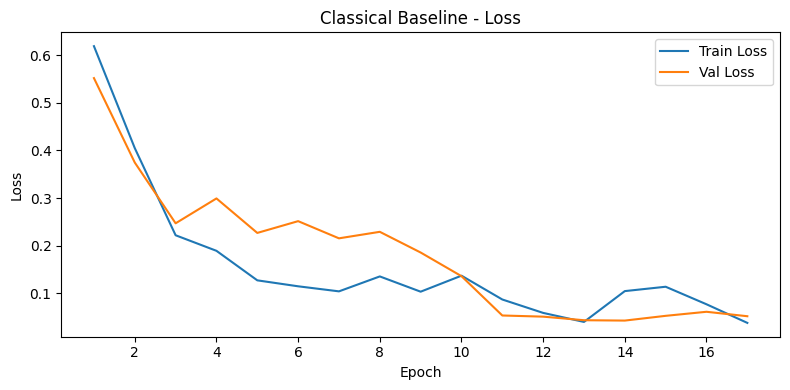

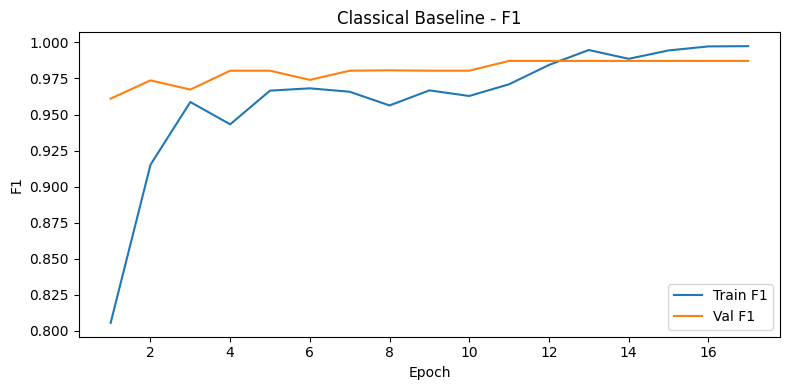

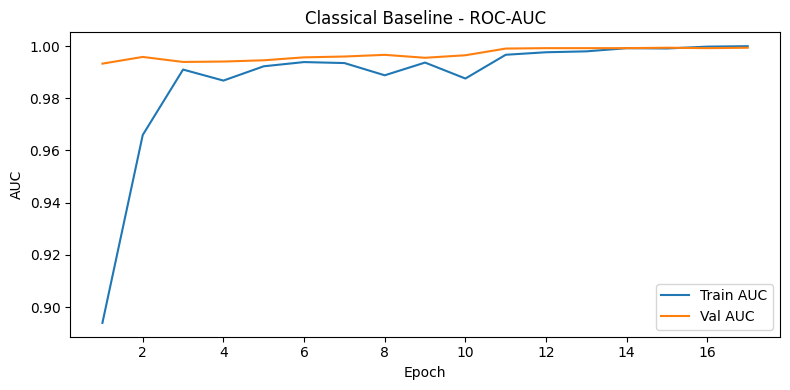

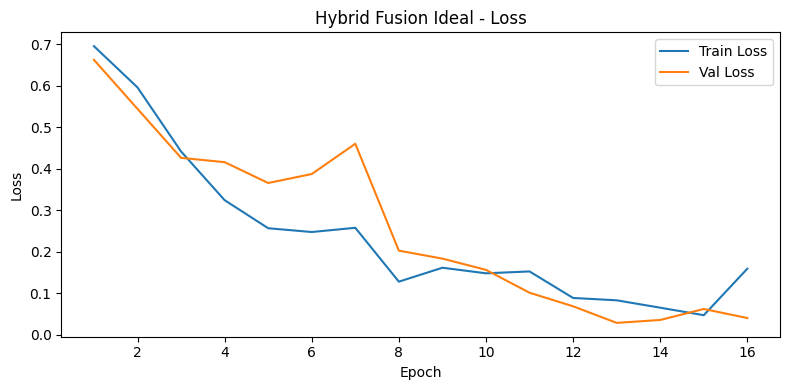

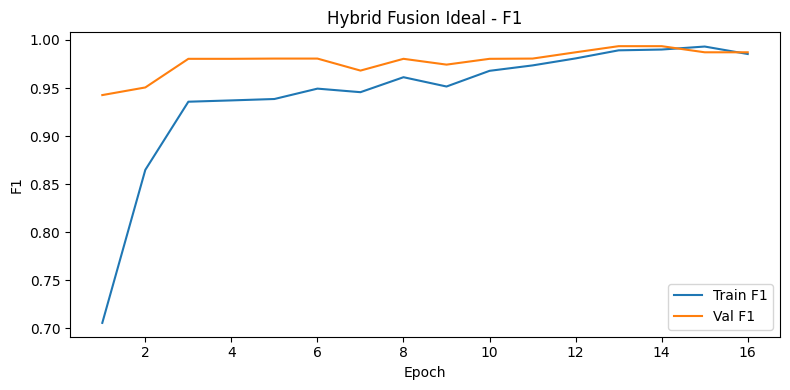

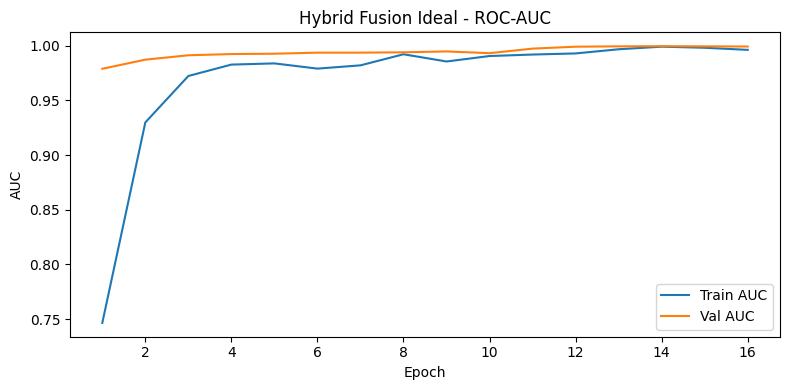

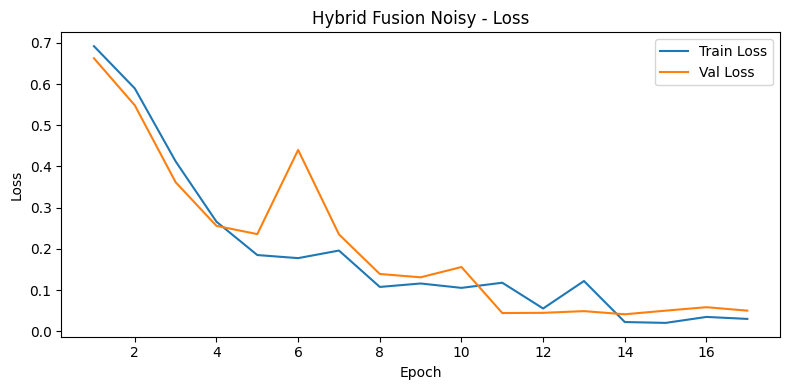

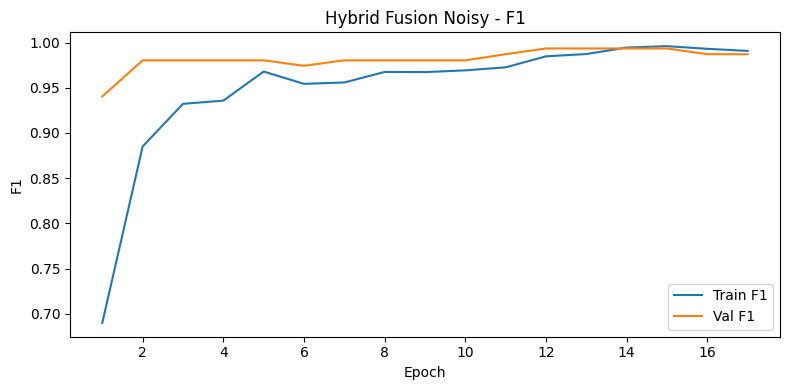

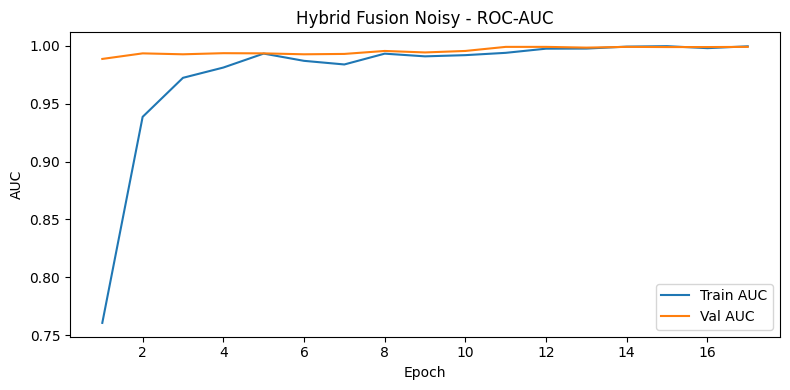

In [ ]:
def plot_history(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_f1"], label="Train F1")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.title(f"{title_prefix} - F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_auc"], label="Train AUC")
    plt.plot(epochs, history["val_auc"], label="Val AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title(f"{title_prefix} - ROC-AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Classical Baseline")
plot_history(ideal_history, "Hybrid Fusion Ideal")
plot_history(noisy_history, "Hybrid Fusion Noisy")

##Confusion matrices and reports

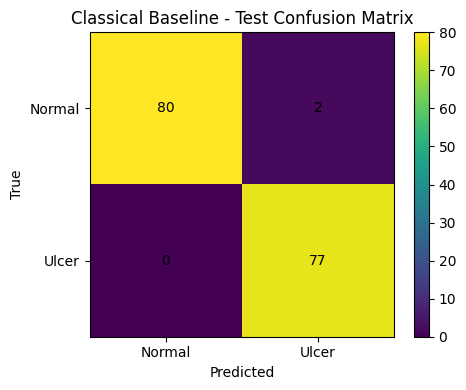

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99        82
       Ulcer       0.97      1.00      0.99        77

    accuracy                           0.99       159
   macro avg       0.99      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159



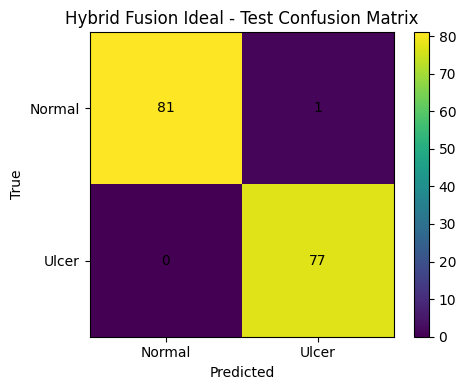

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99        82
       Ulcer       0.99      1.00      0.99        77

    accuracy                           0.99       159
   macro avg       0.99      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159



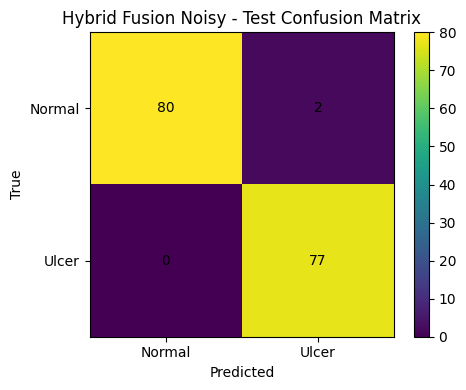

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99        82
       Ulcer       0.97      1.00      0.99        77

    accuracy                           0.99       159
   macro avg       0.99      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159



In [ ]:
def plot_confusion_and_report(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Normal", "Ulcer"])
    plt.yticks([0, 1], ["Normal", "Ulcer"])
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=["Normal", "Ulcer"], zero_division=0))

plot_confusion_and_report(
    baseline_test_y_true, baseline_test_y_prob,
    baseline_results["best_val_threshold"],
    "Classical Baseline - Test Confusion Matrix"
)

plot_confusion_and_report(
    ideal_test_y_true, ideal_test_y_prob,
    ideal_results["best_val_threshold"],
    "Hybrid Fusion Ideal - Test Confusion Matrix"
)

plot_confusion_and_report(
    noisy_test_y_true, noisy_test_y_prob,
    noisy_results["best_val_threshold"],
    "Hybrid Fusion Noisy - Test Confusion Matrix"
)

##ROC comparison

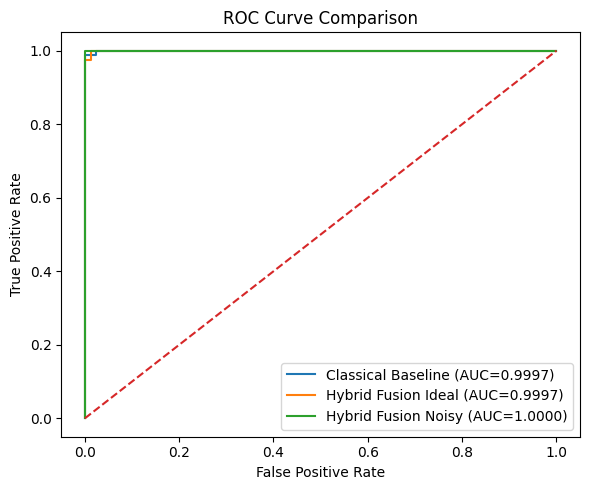

In [ ]:
def plot_roc_curve(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")

plt.figure(figsize=(6, 5))
plot_roc_curve(baseline_test_y_true, baseline_test_y_prob, "Classical Baseline")
plot_roc_curve(ideal_test_y_true, ideal_test_y_prob, "Hybrid Fusion Ideal")
plot_roc_curve(noisy_test_y_true, noisy_test_y_prob, "Hybrid Fusion Noisy")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

##Single image prediction

In [ ]:
single_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict_single_image(image_path, model, threshold):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    x = single_transform(image).unsqueeze(0).to(DEVICE)

    logits = model(x)
    prob = torch.sigmoid(logits).item()
    pred = 1 if prob >= threshold else 0

    print("Image:", image_path)
    print("Predicted:", "Ulcer" if pred == 1 else "Normal")
    print("Ulcer probability:", round(prob, 4))
    print("Threshold:", threshold)

# Example:
# predict_single_image(abnormal_images[0], noisy_model, noisy_results["best_val_threshold"])

##Final saved files check

In [ ]:
print("Saved files:")
for p in sorted(output_dir.glob("*")):
    print("-", p.name)

Saved files:
- best_classical_baseline.pt
- best_hybrid_fusion_ideal.pt
- best_hybrid_fusion_noisy.pt
- comparison.json
- history_classical_baseline.json
- history_hybrid_fusion_ideal.json
- history_hybrid_fusion_noisy.json
- results_classical_baseline.json
- results_hybrid_fusion_ideal.json
- results_hybrid_fusion_noisy.json
